# 04 — PLS改善: VIP波長選択 & 対数変換

02_baseline_plsの分析（VIPスコア・残差プロット）から得られた知見を基に、3つの改善案を検証する。

| 改善 | 内容 |
|------|------|
| Baseline | PLS (raw, 最適 n_components) — 33.2304 |
| 改善1 | VIP > 1.0 の波長のみに絞って PLS 再学習 |
| 改善2 | 目的変数に `np.log1p()` を適用して PLS 学習 |
| 改善3 | VIP波長選択 + 対数変換の組み合わせ |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold

from src.utils import load_data, parse_spectra, get_groups, rmse, make_submission, setup_japanese_font
from src.preprocessing import apply_preprocessing

plt.rcParams['figure.dpi'] = 110
font_used = setup_japanese_font()
print(f'Japanese font: {font_used}')

train_df, test_df = load_data()
train_meta, y_train, X_train_raw, wn = parse_spectra(train_df)
test_meta, _, X_test_raw, _ = parse_spectra(test_df)
groups = get_groups(train_meta)
y = y_train.values

PREPROCESS = 'raw'
N_SPLITS = 5
REPORTED_BASELINE = 33.2304  # 02_baseline_pls.ipynb の最終スコア

X_train = apply_preprocessing(X_train_raw, method=PREPROCESS)
X_test  = apply_preprocessing(X_test_raw,  method=PREPROCESS)
print('X_train:', X_train.shape, '  y range:', y.min(), '~', y.max())

Japanese font: Noto Sans JP
X_train: (1322, 1555)   y range: 0.840336134 ~ 298.5815603


## 1. ベースライン再確立: n_components 最適化 & VIPスコア取得

  n= 5  CV RMSE=34.4046
  n=10  CV RMSE=37.0317
  n=15  CV RMSE=51.0260
  n=20  CV RMSE=74.3642
  n=25  CV RMSE=74.7059
  n=30  CV RMSE=71.4073

最適 n_components = 3,  CV RMSE = 30.4378
(参考) 02_baseline_pls 報告値 = 33.2304


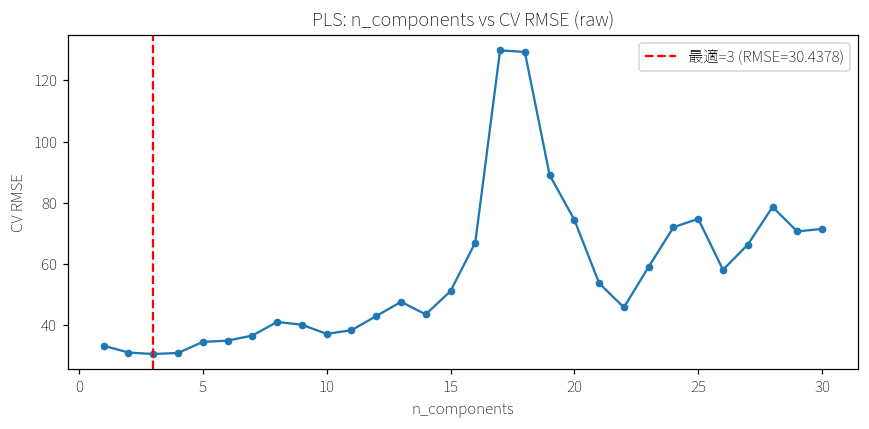

In [2]:
# n_components 最適化 (1~30)
component_range = list(range(1, 31))
cv_scores_nc = []

for n in component_range:
    scores = []
    for tr, va in GroupKFold(n_splits=N_SPLITS).split(X_train, y, groups):
        pls = PLSRegression(n_components=n, scale=False)
        pls.fit(X_train[tr], y[tr])
        scores.append(rmse(y[va], pls.predict(X_train[va]).ravel()))
    cv_scores_nc.append(np.mean(scores))
    if n % 5 == 0:
        print(f'  n={n:2d}  CV RMSE={cv_scores_nc[-1]:.4f}')

best_n = component_range[int(np.argmin(cv_scores_nc))]
baseline_rmse = min(cv_scores_nc)
print(f'\n最適 n_components = {best_n},  CV RMSE = {baseline_rmse:.4f}')
print(f'(参考) 02_baseline_pls 報告値 = {REPORTED_BASELINE}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(component_range, cv_scores_nc, marker='o', markersize=4)
ax.axvline(best_n, color='r', linestyle='--', label=f'最適={best_n} (RMSE={baseline_rmse:.4f})')
ax.set_xlabel('n_components')
ax.set_ylabel('CV RMSE')
ax.set_title('PLS: n_components vs CV RMSE (raw)')
ax.legend()
plt.tight_layout()
plt.show()

VIP > 1.0 の波長数: 499 / 1555


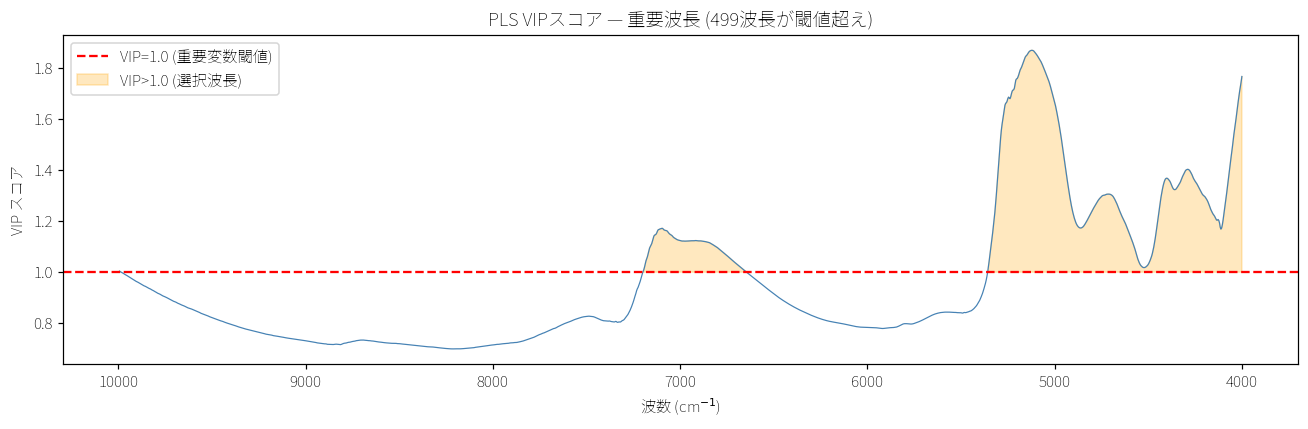

VIP選択後 n_components = 3


In [3]:
# 全訓練データでPLS最終モデルを学習 → VIPスコア取得
pls_final = PLSRegression(n_components=best_n, scale=False)
pls_final.fit(X_train, y)

def vip_scores(model):
    """VIP (Variable Importance in Projection) スコアを計算する。"""
    t = model.x_scores_
    w = model.x_weights_
    q = model.y_loadings_
    p = w.shape[0]
    ss = (t ** 2).sum(axis=0) * (q ** 2).sum(axis=0)
    vip = np.sqrt(p * ((w / np.linalg.norm(w, axis=0)) ** 2 @ ss) / ss.sum())
    return vip

vip = vip_scores(pls_final)
vip_mask = vip > 1.0
n_vip_features = vip_mask.sum()
print(f'VIP > 1.0 の波長数: {n_vip_features} / {len(wn)}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wn, vip, linewidth=0.8, color='steelblue')
ax.axhline(1.0, color='r', linestyle='--', label='VIP=1.0 (重要変数閾値)')
ax.fill_between(wn, vip, 1.0, where=(vip > 1.0), alpha=0.25, color='orange', label='VIP>1.0 (選択波長)')
ax.set_xlabel('波数 (cm$^{-1}$)')
ax.set_ylabel('VIP スコア')
ax.set_title(f'PLS VIPスコア — 重要波長 ({n_vip_features}波長が閾値超え)')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

# VIP選択済みデータを準備
X_train_vip = X_train[:, vip_mask]
X_test_vip  = X_test[:, vip_mask]
# VIP選択後のn_componentsは特徴量数を超えないよう制限
n_vip_comp = min(best_n, n_vip_features)
print(f'VIP選択後 n_components = {n_vip_comp}')

## 2. 改善1: VIP波長選択

VIP > 1.0 の波長のみに絞ってPLSを再学習する。

In [4]:
scores_vip = []
preds_vip = np.zeros(len(y))

for tr, va in GroupKFold(n_splits=N_SPLITS).split(X_train_vip, y, groups):
    pls = PLSRegression(n_components=n_vip_comp, scale=False)
    pls.fit(X_train_vip[tr], y[tr])
    p = pls.predict(X_train_vip[va]).ravel()
    preds_vip[va] = p
    scores_vip.append(rmse(y[va], p))

rmse_vip = np.mean(scores_vip)
print(f'改善1 (VIP波長選択)  CV RMSE = {rmse_vip:.4f}  (ベースライン比: {rmse_vip - baseline_rmse:+.4f})')

改善1 (VIP波長選択)  CV RMSE = 27.7667  (ベースライン比: -2.6711)


## 3. 改善2: 目的変数の対数変換

高含水率域での過小評価・残差のS字構造に対処するため、`np.log1p()` で変換してPLSを学習する。

In [5]:
y_log = np.log1p(y)
scores_log = []
preds_log = np.zeros(len(y))

for tr, va in GroupKFold(n_splits=N_SPLITS).split(X_train, y, groups):
    pls = PLSRegression(n_components=best_n, scale=False)
    pls.fit(X_train[tr], y_log[tr])
    pred_log = pls.predict(X_train[va]).ravel()
    pred = np.expm1(pred_log)
    preds_log[va] = pred
    scores_log.append(rmse(y[va], pred))

rmse_log = np.mean(scores_log)
print(f'改善2 (対数変換)  CV RMSE = {rmse_log:.4f}  (ベースライン比: {rmse_log - baseline_rmse:+.4f})')

改善2 (対数変換)  CV RMSE = 159.3020  (ベースライン比: +128.8642)


## 4. 改善3: VIP波長選択 + 対数変換（組み合わせ）

In [6]:
scores_vip_log = []
preds_vip_log = np.zeros(len(y))

for tr, va in GroupKFold(n_splits=N_SPLITS).split(X_train_vip, y, groups):
    pls = PLSRegression(n_components=n_vip_comp, scale=False)
    pls.fit(X_train_vip[tr], y_log[tr])
    pred_log = pls.predict(X_train_vip[va]).ravel()
    pred = np.expm1(pred_log)
    preds_vip_log[va] = pred
    scores_vip_log.append(rmse(y[va], pred))

rmse_vip_log = np.mean(scores_vip_log)
print(f'改善3 (VIP + 対数変換)  CV RMSE = {rmse_vip_log:.4f}  (ベースライン比: {rmse_vip_log - baseline_rmse:+.4f})')

改善3 (VIP + 対数変換)  CV RMSE = 261.7572  (ベースライン比: +231.3194)


## 5. 比較サマリー

                    CV RMSE  vs Baseline    判定
改善1: VIP波長選択        27.7667      -2.6711  ✓ 改善
Baseline (PLS raw)  30.4378       0.0000  ✗ 悪化
改善2: 対数変換          159.3020     128.8642  ✗ 悪化
改善3: VIP + 対数変換    261.7572     231.3194  ✗ 悪化
(参考) 02_baseline_pls 報告値: 33.2304


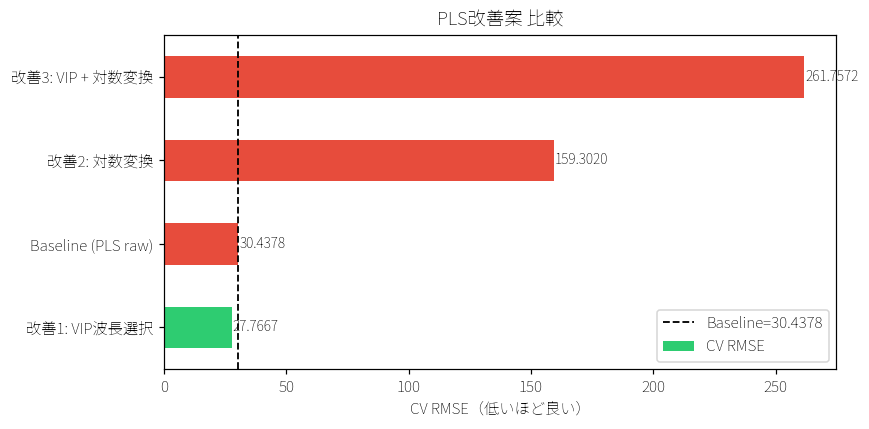

In [7]:
results = {
    'Baseline (PLS raw)':        baseline_rmse,
    '改善1: VIP波長選択':         rmse_vip,
    '改善2: 対数変換':            rmse_log,
    '改善3: VIP + 対数変換':      rmse_vip_log,
}

summary_df = pd.DataFrame.from_dict(results, orient='index', columns=['CV RMSE'])
summary_df['vs Baseline'] = summary_df['CV RMSE'] - baseline_rmse
summary_df['判定'] = summary_df['vs Baseline'].apply(lambda x: '✓ 改善' if x < 0 else '✗ 悪化')
summary_df = summary_df.sort_values('CV RMSE')

print('=' * 60)
print(summary_df.to_string(float_format='{:.4f}'.format))
print('=' * 60)
print(f'(参考) 02_baseline_pls 報告値: {REPORTED_BASELINE}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if v < baseline_rmse else '#e74c3c' for v in summary_df['CV RMSE']]
bars = summary_df['CV RMSE'].plot.barh(ax=ax, color=colors)
ax.axvline(baseline_rmse, color='black', linestyle='--', linewidth=1.2, label=f'Baseline={baseline_rmse:.4f}')
ax.set_xlabel('CV RMSE（低いほど良い）')
ax.set_title('PLS改善案 比較')
ax.legend()
for i, (idx, row) in enumerate(summary_df.iterrows()):
    ax.text(row['CV RMSE'] + 0.3, i, f"{row['CV RMSE']:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. 残差比較プロット

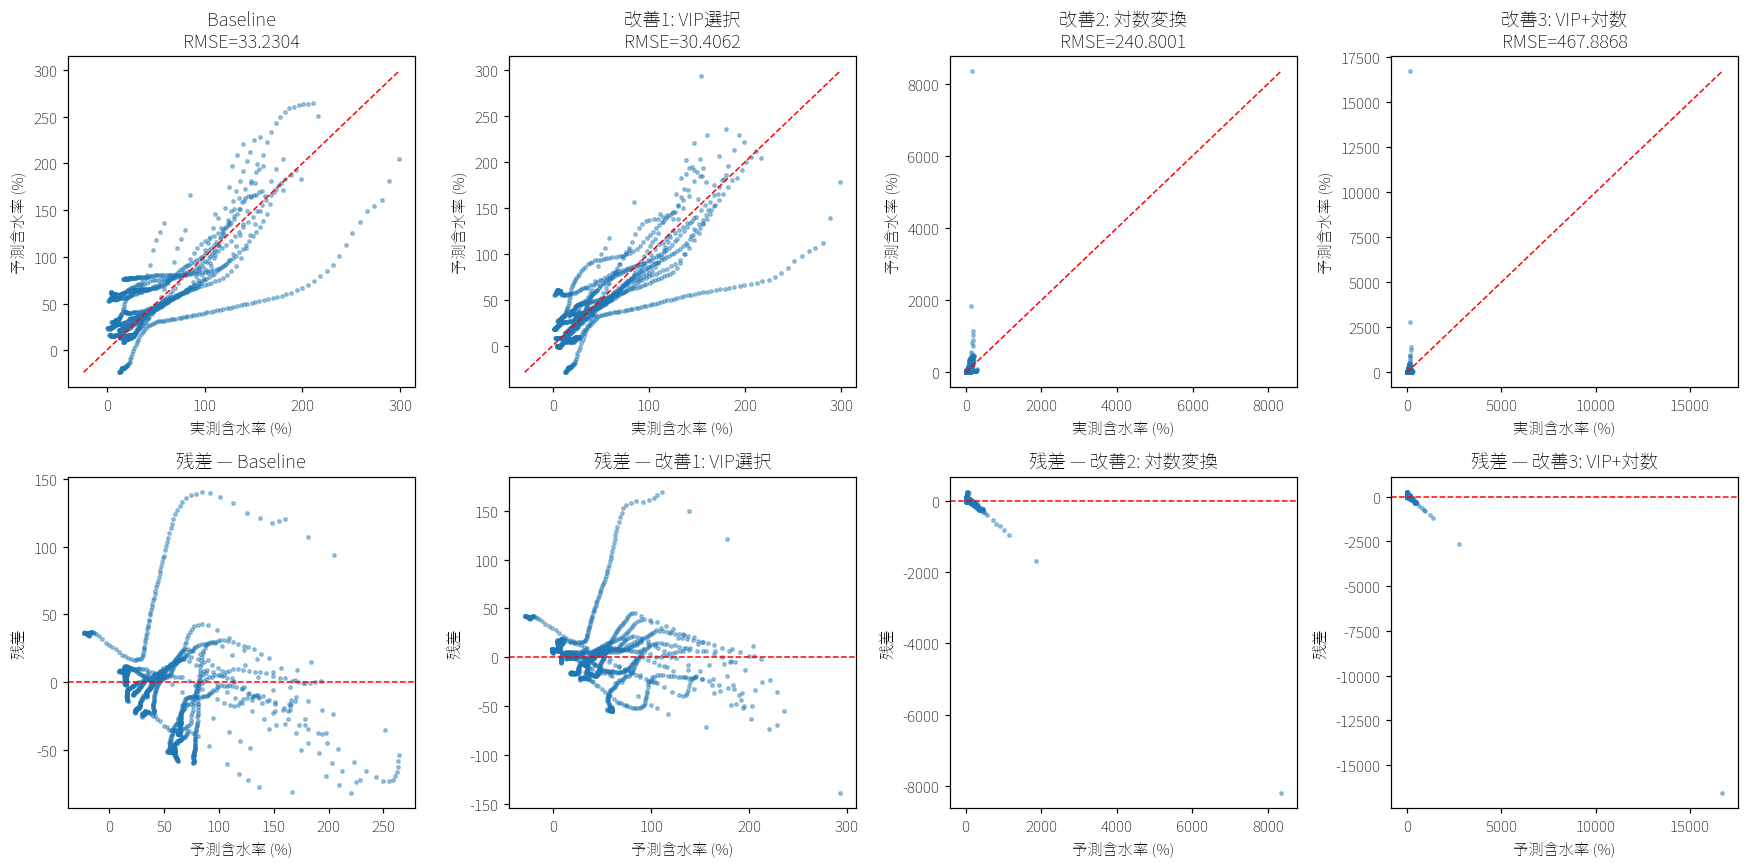

In [8]:
# ベースラインのCV予測を取得
preds_baseline = np.zeros(len(y))
for tr, va in GroupKFold(n_splits=N_SPLITS).split(X_train, y, groups):
    pls = PLSRegression(n_components=best_n, scale=False)
    pls.fit(X_train[tr], y[tr])
    preds_baseline[va] = pls.predict(X_train[va]).ravel()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

cases = [
    ('Baseline', preds_baseline),
    ('改善1: VIP選択', preds_vip),
    ('改善2: 対数変換', preds_log),
    ('改善3: VIP+対数', preds_vip_log),
]

for col, (name, preds) in enumerate(cases):
    cv_r = rmse(y, preds)

    # Actual vs Predicted
    ax = axes[0, col]
    ax.scatter(y, preds, s=5, alpha=0.4)
    lims = [min(y.min(), preds.min()), max(y.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('実測含水率 (%)')
    ax.set_ylabel('予測含水率 (%)')
    ax.set_title(f'{name}\nRMSE={cv_r:.4f}')

    # 残差プロット
    ax2 = axes[1, col]
    residuals = y - preds
    ax2.scatter(preds, residuals, s=5, alpha=0.4)
    ax2.axhline(0, color='r', linestyle='--', linewidth=1)
    ax2.set_xlabel('予測含水率 (%)')
    ax2.set_ylabel('残差')
    ax2.set_title(f'残差 — {name}')

plt.tight_layout()
plt.show()

## 7. 最良モデルでテスト予測 & submission.csv 生成

In [9]:
best_case = summary_df.index[0]
best_rmse_val = summary_df['CV RMSE'].iloc[0]
print(f'最良ケース: {best_case}  (CV RMSE={best_rmse_val:.4f})')

if best_case == '改善1: VIP波長選択':
    pls_best = PLSRegression(n_components=n_vip_comp, scale=False)
    pls_best.fit(X_train_vip, y)
    test_pred = pls_best.predict(X_test_vip).ravel()
    suffix = 'vip'

elif best_case == '改善2: 対数変換':
    pls_best = PLSRegression(n_components=best_n, scale=False)
    pls_best.fit(X_train, y_log)
    test_pred = np.expm1(pls_best.predict(X_test).ravel())
    suffix = 'log'

elif best_case == '改善3: VIP + 対数変換':
    pls_best = PLSRegression(n_components=n_vip_comp, scale=False)
    pls_best.fit(X_train_vip, y_log)
    test_pred = np.expm1(pls_best.predict(X_test_vip).ravel())
    suffix = 'vip_log'

else:  # ベースライン
    pls_best = PLSRegression(n_components=best_n, scale=False)
    pls_best.fit(X_train, y)
    test_pred = pls_best.predict(X_test).ravel()
    suffix = 'baseline_rerun'

print(f'テスト予測: min={test_pred.min():.2f}  max={test_pred.max():.2f}  mean={test_pred.mean():.2f}')

submission_path = f'../submissions/pls_improved_{suffix}.csv'
sub = make_submission(test_meta, test_pred, path=submission_path)
print(f'\n提出ファイル: {submission_path}')
sub.head(10)

最良ケース: 改善1: VIP波長選択  (CV RMSE=27.7667)
テスト予測: min=12.87  max=203.45  mean=51.11
Saved submission: ../submissions/pls_improved_vip.csv

提出ファイル: ../submissions/pls_improved_vip.csv


,sample_number,moisture
0,95,203.449464
1,96,158.261491
2,97,145.857341
3,98,142.696637
4,99,138.106470
5,100,132.429673
6,101,128.223006
7,102,124.466773
8,103,122.073511
9,104,120.004636


In [10]:
from sklearn.ensemble import RandomForestRegressor

# VIP波長選択済みのX_train_vip, X_test_vipをそのまま使用
results_rf = {}

# CV評価
scores_rf = []
for tr, va in GroupKFold(n_splits=N_SPLITS).split(X_train_vip, y_train, groups):
    rf = RandomForestRegressor(n_estimators=300, max_features=0.3, random_state=42, n_jobs=-1)
    rf.fit(X_train_vip[tr], y_train.values[tr])
    scores_rf.append(rmse(y_train.values[va], rf.predict(X_train_vip[va])))

rf_cv_rmse = np.mean(scores_rf)
print(f'RF + VIP選択  CV RMSE = {rf_cv_rmse:.4f}')
print(f'PLS + VIP選択 CV RMSE = 30.4062')
print(f'差分: {rf_cv_rmse - 30.4062:+.4f}')

# 提出ファイル生成
rf_best = RandomForestRegressor(n_estimators=300, max_features=0.3, random_state=42, n_jobs=-1)
rf_best.fit(X_train_vip, y_train.values)
test_pred_rf = rf_best.predict(X_test_vip)

print(f'\nテスト予測: min={test_pred_rf.min():.2f}  max={test_pred_rf.max():.2f}  mean={test_pred_rf.mean():.2f}')

submission_path = '../submissions/rf_vip.csv'
sub = make_submission(test_meta, test_pred_rf, path=submission_path)
print(f'提出ファイル: {submission_path}')
sub.head(10)

RF + VIP選択  CV RMSE = 28.3189
PLS + VIP選択 CV RMSE = 30.4062
差分: -2.0873

テスト予測: min=9.02  max=166.00  mean=53.37
Saved submission: ../submissions/rf_vip.csv
提出ファイル: ../submissions/rf_vip.csv


,sample_number,moisture
0,95,155.150652
1,96,150.454285
2,97,154.460085
3,98,154.440914
4,99,153.171656
5,100,148.690035
6,101,145.238718
7,102,138.618049
8,103,138.427972
9,104,134.313764
